#Neural Network - A Simple Perceptron |
Assignment

1. What is Deep Learning? Briefly describe how it evolved and how it differs
from traditional machine learning.
-  Deep Learning is an advanced branch of machine learning that uses multi-layered artificial neural networks to learn patterns from large amounts of data. It is inspired by the structure and working of the human brain. Deep learning evolved from early neural network models like the perceptron (1950s), gained importance with the introduction of backpropagation (1980s), and became highly successful after 2006 due to increased computing power, availability of big data, and improved algorithms. Unlike traditional machine learning, which requires manual feature extraction and works well with limited data, deep learning automatically learns features from raw data and performs better on complex tasks like image recognition, speech processing, and natural language understanding. It requires powerful hardware like GPUs and large datasets but provides high accuracy and better performance in real-world applications.

2. Explain the basic architecture and functioning of a Perceptron. What are its limitations?
- A Perceptron is the simplest neural network model consisting of input nodes, weights, a bias, a summation unit, and an activation function. It works by multiplying each input with its weight, adding them with the bias, and passing the result through an activation function to produce an output. During training, it adjusts its weights based on errors to improve predictions. However, a perceptron has limitations — it can only solve linearly separable problems, cannot handle complex or non-linear tasks like XOR, and is limited to simple binary classification.

3. Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.
-  Activation functions give neural networks the ability to learn complex patterns by introducing non-linearity into the model. Without activation functions, a neural network would behave like a simple linear model and fail to solve complex problems such as image or speech recognition. The Sigmoid function maps input values between 0 and 1 and is useful for binary classification, but it suffers from vanishing gradients and slow training. The Tanh function maps values between –1 and 1, making it zero-centered and often more effective than Sigmoid, but it can still face vanishing gradient problems. The ReLU (Rectified Linear Unit) function outputs zero for negative values and the input itself for positive values. ReLU is widely used in deep networks because it is simple, fast, and reduces the vanishing gradient issue, although it can cause “dead neurons” when values stay negative. Overall, ReLU is preferred in most deep learning models due to better performance and faster convergence.

4. What is the difference between Loss function and Cost function in neural
networks? Provide examples.
-  A Loss function measures the error for a single training example, while a Cost function represents the average loss over the entire training dataset. In simple terms, loss is calculated per sample, and cost is the overall measure used to update model weights during training. Loss functions help identify how wrong the model's prediction is for one instance, while cost functions help optimize performance over all samples.
Examples:
*Loss function: Mean Squared Error (for one sample), Binary Cross-Entropy (for one input-output pair)
*Cost function: Average Mean Squared Error, Average Cross-Entropy over the full dataset
So, loss is individual error, and cost is the aggregated error used to improve the model.

5. What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.
-  Optimizers in neural networks play a key role in training by updating model weights to minimize the loss function and improve prediction accuracy. They determine how quickly and efficiently the model learns patterns from data.

Gradient Descent is the simplest optimizer that updates weights by moving in the direction opposite to the gradient of the loss. It is easy to understand and works well for small datasets, but it can be slow, sensitive to learning rate, and may get stuck in local minima.

RMSprop improves training speed by adapting the learning rate for each parameter using a moving average of squared gradients. It works well for noisy or non-stationary data, making it suitable for deep learning tasks like RNNs.

Adam (Adaptive Moment Estimation) combines the benefits of momentum and RMSprop by using averages of both past gradients and squared gradients. It converges faster, performs well in most situations, and is widely used in practice, although it may sometimes lead to overfitting or weaker generalization.



In [1]:
'''6. Write a Python program to implement a single-layer perceptron from
scratch using NumPy to solve the logical AND gate.'''
import numpy as np

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

for epoch in range(epochs):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = 1 if z >= 0 else 0
        error = y[i] - prediction
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

print("Trained Weights:", weights)
print("Trained Bias:", bias)

for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    prediction = 1 if z >= 0 else 0
    print(f"{X[i]} -> {prediction}")


Trained Weights: [0.2 0.1]
Trained Bias: -0.20000000000000004
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


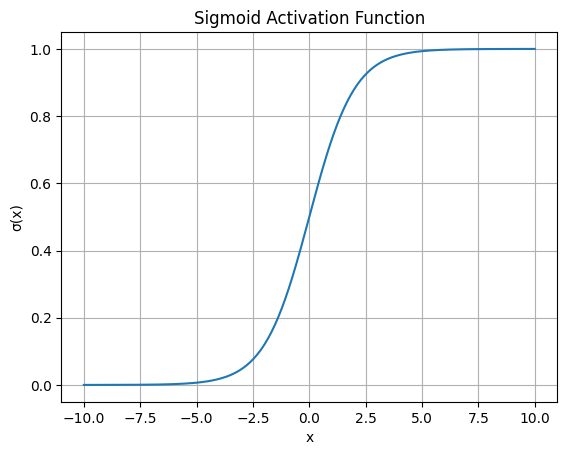

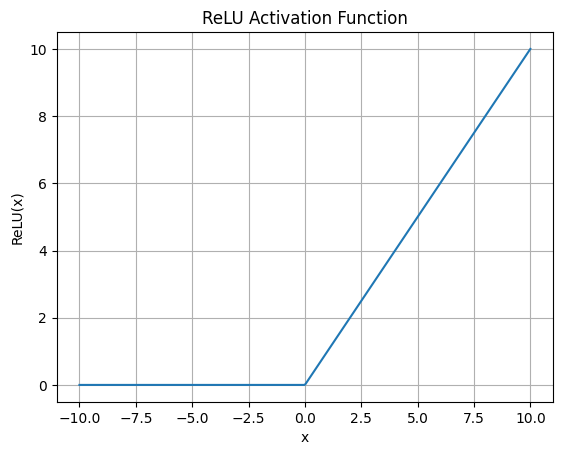

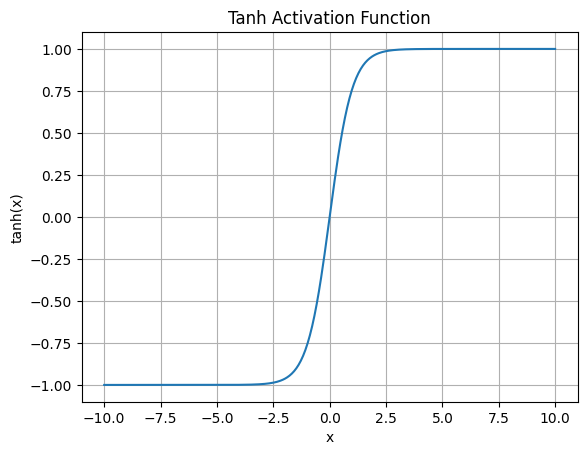

In [2]:
'''7. Implement and visualize Sigmoid, ReLU, and Tanh activation functions
using Matplotlib.'''
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure()
plt.plot(x, sigmoid)
plt.title("Sigmoid Activation Function")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x, relu)
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x, tanh)
plt.title("Tanh Activation Function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show()


In [3]:
'''8. Use Keras to build and train a simple multilayer neural network on the
MNIST digits dataset. Print the training accuracy.'''
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)

print("Training Accuracy:", history.history['accuracy'][-1])



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8344 - loss: 0.6080
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9592 - loss: 0.1401
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9728 - loss: 0.0917
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9791 - loss: 0.0697
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9834 - loss: 0.0534
Training Accuracy: 0.9833999872207642


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7260 - loss: 0.7994 - val_accuracy: 0.8537 - val_loss: 0.4176
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8527 - loss: 0.4174 - val_accuracy: 0.8494 - val_loss: 0.4086
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8694 - loss: 0.3594 - val_accuracy: 0.8572 - val_loss: 0.3908
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8795 - loss: 0.3282 - val_accuracy: 0.8734 - val_loss: 0.3510
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8866 - loss: 0.3120 - val_accuracy: 0.8681 - val_loss: 0.3757
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8895 - loss: 0.2994 - val_accuracy: 0.8790 - val_loss: 0.3351
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6

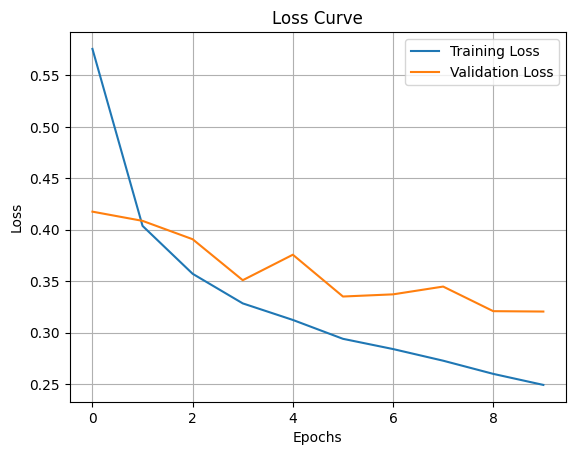

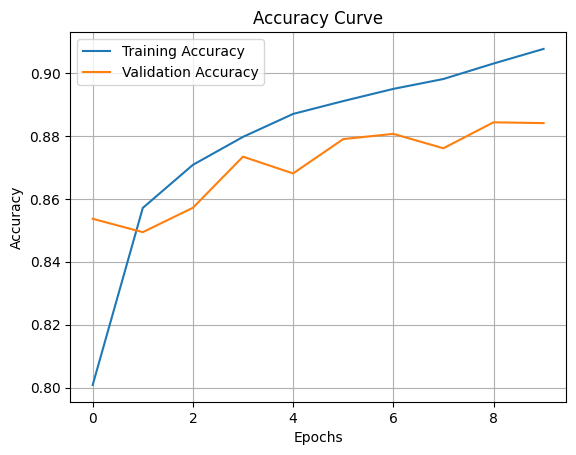

In [4]:
'''9. : Visualize the loss and accuracy curves for a neural network model trained
on the Fashion MNIST dataset. Interpret the training behavior.'''
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid(True)
plt.show()


10. For a bank fraud-detection system with large, imbalanced transactional data, the real-time data science workflow would focus on building a robust deep learning model that can detect rare fraud cases while minimizing false alarms.

Model Design:
I would design a multilayer neural network since the dataset includes structured numerical and categorical features. The architecture would include:
Input layer based on feature count (after one-hot encoding or embeddings for categorical fields like merchant ID).
2–3 fully connected hidden layers with units decreasing gradually (e.g., 256 → 128 → 64).
Output layer with a single neuron for binary classification.
This hierarchy helps the network learn complex patterns in transactional behavior.

Activation & Loss Function:
Hidden layers: ReLU activation, since it is efficient and prevents vanishing gradients.
Output layer: Sigmoid activation, because the task requires binary probability output.
Loss function: Binary Cross-Entropy with class weights or Focal Loss, since the dataset is highly imbalanced and we must focus on minority (fraud) cases.

Training & Evaluation with Imbalance Handling:
To properly train with imbalance:
Use class weights so fraud samples contribute more to the loss.
Optionally use oversampling (SMOTE) or undersampling techniques.
Monitor performance using Precision, Recall, and F1-Score, not just accuracy.
Use ROC-AUC and Precision-Recall AUC, since they reflect model ability on rare classes.
A validation split and cross-validation would be applied to ensure generalization.

Optimizer & Overfitting Prevention:
Use Adam optimizer, as it converges quickly and works well on structured data.
Prevent overfitting using:
Dropout layers (e.g., 0.2–0.4)
L2 regularization
Early stopping based on validation loss
Batch normalization for stable training